In [1]:
# importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_parquet('dadosMinas/bdqueimadas_final.parquet')

In [3]:
# Criando dataframe apenas com dados do Cerrado
df_cerrado = df[df['Bioma'] == 'Cerrado'].copy()

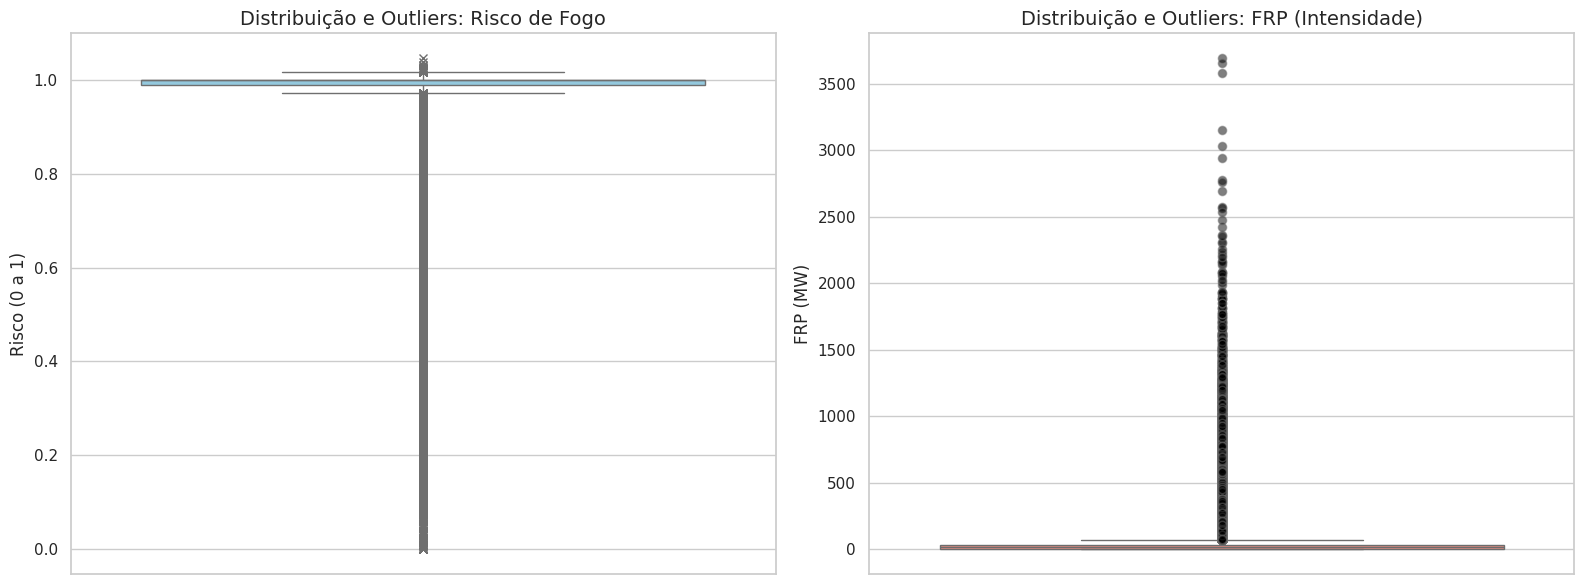

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_cerrado['RiscoFogo'], color='skyblue', flierprops={"marker": "x", "markerfacecolor": "red"})
plt.title('Distribuição e Outliers: Risco de Fogo', fontsize=14)
plt.ylabel('Risco (0 a 1)', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cerrado['FRP'], color='salmon', flierprops={"marker": "o", "markerfacecolor": "black", "alpha": 0.5})
plt.title('Distribuição e Outliers: FRP (Intensidade)', fontsize=14)
plt.ylabel('FRP (MW)', fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
total_abaixo_08 = (df_cerrado['RiscoFogo'] < 0.8).sum()
total_geral = len(df_cerrado)
percentual = (total_abaixo_08 / total_geral) * 100

print(f"Quantidade de focos com Risco de Fogo < 0.8: {total_abaixo_08}")
print(f"Total de registros no Cerrado: {total_geral}")
print(f"Isso representa {percentual:.2f}% do seu dataset!")

Quantidade de focos com Risco de Fogo < 0.8: 157786
Total de registros no Cerrado: 1310222
Isso representa 12.04% do seu dataset!


In [6]:
df_risco_baixo = df_cerrado[df_cerrado['RiscoFogo'] < 0.8]
df_risco_alto = df_cerrado[df_cerrado['RiscoFogo'] >= 0.8]

df_risco_alto_amostra = df_risco_alto.sample(n=len(df_risco_baixo), random_state=42)

df_balanceado = pd.concat([df_risco_baixo, df_risco_alto_amostra])

df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Novo tamanho do Dataset: {len(df_balanceado)} linhas")
print(f"Risco Baixo (<0.8): {len(df_balanceado[df_balanceado['RiscoFogo'] < 0.8])} linhas")
print(f"Risco Alto (>=0.8): {len(df_balanceado[df_balanceado['RiscoFogo'] >= 0.8])} linhas")

Novo tamanho do Dataset: 315572 linhas
Risco Baixo (<0.8): 157786 linhas
Risco Alto (>=0.8): 157786 linhas


In [23]:
df_balanceado['DataHora'] = pd.to_datetime(df_balanceado['DataHora'])
df_balanceado['Mes'] = df_balanceado['DataHora'].dt.month
df_balanceado['Hora'] = df_balanceado['DataHora'].dt.hour

X = df_balanceado[['DiaSemChuva', 'Precipitacao', 'Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms', 'Mes', 'Hora', 'Latitude', 'Longitude']]
y_binario = (df_balanceado['RiscoFogo'] >= 0.8).astype(int)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y_binario, test_size=0.2, random_state=42)

In [8]:
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 15, 20], 
    'min_samples_split': [5, 10], 
    'min_samples_leaf': [2, 4]    
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='accuracy',
    verbose=2, 
    n_jobs=-1
)

grid_rf.fit(X_treino, y_treino)

print(f"Melhores Parâmetros RF: {grid_rf.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits


[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  48.9s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  55.3s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  57.5s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time= 1.0min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time= 1.0min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 1.1min
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  39.2s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  46.5s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  54.5s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total 

In [9]:
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] 
}

xgb_base = XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_treino, y_treino)

print(f"Melhores Parâmetros XGB: {grid_xgb.best_params_}")

Fitting 3 folds for each of 192 candidates, totalling 576 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   4.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   4.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   4.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.8; total time=   5.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.8; total time=   5.2s
[CV] END 

/home/vcollares/.venv/lib64/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=1.0; total time=   5.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.8; total time=  17.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=  17.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.8; total time=  17.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.8; total time=  17.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=  13.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=  13.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=8, n_estimators=100, subsample=0.8; total time=   6.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estima

Acurácia FINAL Random Forest (Limiar 30%): 92.31%



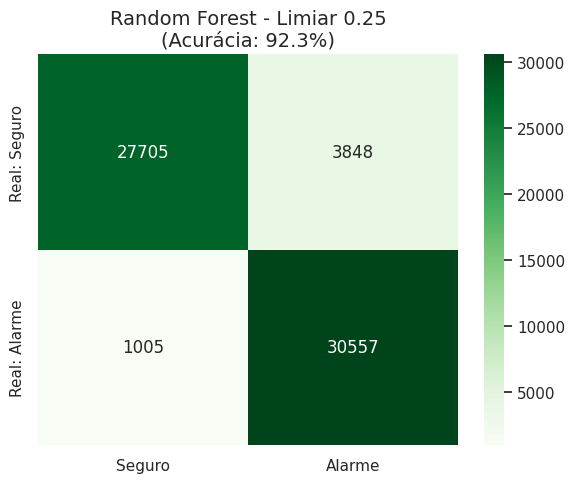

In [ ]:
modelo_rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo_rf_final.fit(X_treino, y_treino)

limiar = 0.25
probabilidades_rf = modelo_rf_final.predict_proba(X_teste)[:, 1]
previsoes_rf_medrosas = (probabilidades_rf >= limiar).astype(int)

acc_rf = accuracy_score(y_teste, previsoes_rf_medrosas)
print(f"Acurácia FINAL Random Forest (Limiar 25%): {acc_rf * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_rf = confusion_matrix(y_teste, previsoes_rf_medrosas)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Seguro', 'Alarme'], yticklabels=['Real: Seguro', 'Real: Alarme'])
plt.title(f'Random Forest - Limiar {limiar}\n(Acurácia: {acc_rf*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()

Acurácia FINAL XGBoost (Limiar 25%): 94.61%



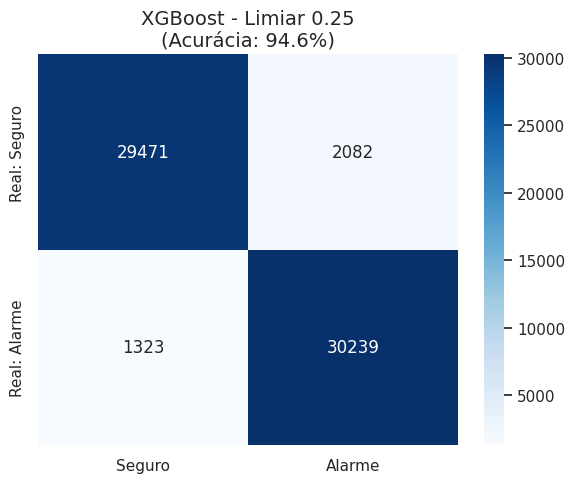

In [42]:
modelo_xgb_final = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=1.0,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

modelo_xgb_final.fit(X_treino, y_treino)

limiar = 0.25
probabilidades_xgb = modelo_xgb_final.predict_proba(X_teste)[:, 1]
previsoes_xgb_medrosas = (probabilidades_xgb >= limiar).astype(int)

acc_xgb = accuracy_score(y_teste, previsoes_xgb_medrosas)
print(f"Acurácia FINAL XGBoost (Limiar 25%): {acc_xgb * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_xgb = confusion_matrix(y_teste, previsoes_xgb_medrosas)
sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Seguro', 'Alarme'], yticklabels=['Real: Seguro', 'Real: Alarme'])
plt.title(f'XGBoost - Limiar {limiar}\n(Acurácia: {acc_xgb*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()